# Determining electric conductivity $\sigma$ and magnetic field $B$

### Imports

In [1]:

from pathlib import Path
import numpy as np


import matplotlib.pyplot as plt


from ppvm_py.utils import load_object

from ppvm_py.plotting import plot_heatmap
from ppvm_py.plotting import generate_2d_video

from ppvm_py.data_processing.yz_slice import print_yz_slice_example_from_parsed_data
from ppvm_py.data_processing.utils import create_index_to_coord_map

from ppvm_py.sigma_and_b_estimation import calc_conductivity_with_z

### General Args

In [2]:
# IMPORTANT: Restart Kernel when swapping datasets to reload them!
Ha = 300

if Ha == 300:
    slice_folder_path = Path("../../../../data/4pi_re1000_ha300.360_ch28.p1/SliceYZ_x0015/")
elif Ha == 1000:
    slice_folder_path = Path("../../../../data/4pi_re1000_ha1000.384.pi/SliceYZ_x0015/")

# Estimates from evaluations
sigma = -1  # According to the results here.
B_z = -1  # According to the results here.

animation_folder = Path("animations")

### Load Data

In [3]:
fld_path = slice_folder_path / Path("pkl/sliceYZ_x0015_fld.pkl")
gradF_path = slice_folder_path / Path("pkl/sliceYZ_x0015_gradF.pkl")

In [4]:
if 'fld_data' not in locals():
    fld_data = load_object(fld_path)
fld_data['index_to_coord_map'] = create_index_to_coord_map(fld_data['coord_to_index_map'])
print_yz_slice_example_from_parsed_data(fld_data)
print()

if 'gradF_data' not in locals():
    gradF_data = load_object(gradF_path)
gradF_data['index_to_coord_map'] = create_index_to_coord_map(gradF_data['coord_to_index_map'])
print_yz_slice_example_from_parsed_data(gradF_data)

Object successfully loaded from C:\Users\hydro\Documents\PhD\nuclear_fusion_cooling\data\4pi_re1000_ha300.360_ch28.p1\SliceYZ_x0015\pkl\sliceYZ_x0015_fld.pkl
The data looks as follows:
N (number of snapshots) = 20000
n_y (grid height) = 46, n_z (grid width) = 46, n_v (number of variables) = 8
Labels:
['vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
Preview of the first snapshot (first 2 y, first 2 z) with coordinates:
  (y=-1.00, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.027423e-01  0.000000e+00
  0.000000e+00 -5.862112e-04  1.594463e+00]
  (y=-1.00, z=-0.99): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.175437e-01  0.000000e+00
 -4.764620e-01 -5.860972e-04  1.599692e+00]
  (y=-0.99, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -1.220912e-01  2.072063e+00
  0.000000e+00 -5.841985e-04  1.580085e+00]
  (y=-0.99, z=-0.99): [ 2.256158e+00 -1.132797e-01  1.513446e-02 -2.226841e-01 -5.704941e-02
 -3.949543e-01 -5.842091e-04  1.584242e+00]

Object successfully loaded from

### Ohm's Law

$\mathbf{J} = \sigma (\mathbf{E} + \mathbf{v} \times \mathbf{B})$

In vector form:

$\mathbf{J} = \begin{pmatrix} j_x \\ j_y \\ j_z \end{pmatrix} = \sigma \begin{pmatrix} E_x + (v_y B_z - v_z B_y) \\ E_y + (v_z B_x - v_x B_z) \\ E_z + (v_x B_y - v_y B_x) \end{pmatrix}$

We know that $B$ is only present in $z$-direction.

$\begin{pmatrix} j_x \\ j_y \\ j_z \end{pmatrix} = \sigma \left(\begin{pmatrix}E_x \\ E_y \\ E_z \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\partial \varphi}{\partial x} \\ \frac{\partial \varphi}{\partial y} \\ \frac{\partial \varphi}{\partial 
z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$\approx \sigma \left(\begin{pmatrix} \frac{\Delta \varphi_x}{\Delta l_x} \\ \frac{\Delta \varphi_y}{\Delta l_y} \\ \frac{\Delta \varphi_z}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \\ \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} \\ \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

So, we have:

$ v_y = \frac{1}{B_z} \left( \frac{j_x}{\sigma} - \frac{\partial \varphi}{\partial x} \right) \approx \frac{1}{B_z} \left( \frac{j_x}{\sigma} - \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \right) $

$ v_x = \frac{1}{B_z} \left( \frac{\partial \varphi}{\partial y} - \frac{j_y}{\sigma} \right) \approx \frac{1}{B_z} \left( \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} - \frac{j_y}{\sigma} \right) $

$ \frac{j_z}{\sigma} = \frac{\partial \varphi}{\partial z} \approx \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z}$

## Ohm's Law in z-coord

### Find 0 Entries

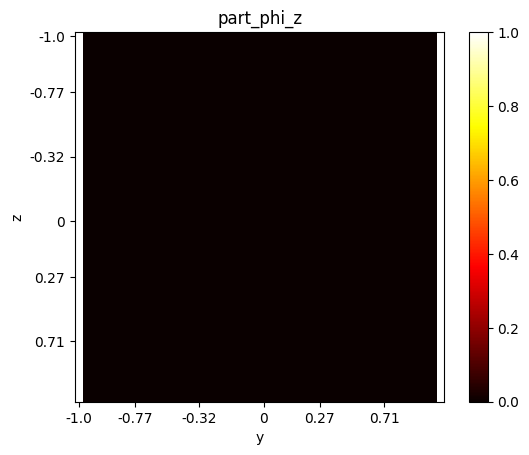

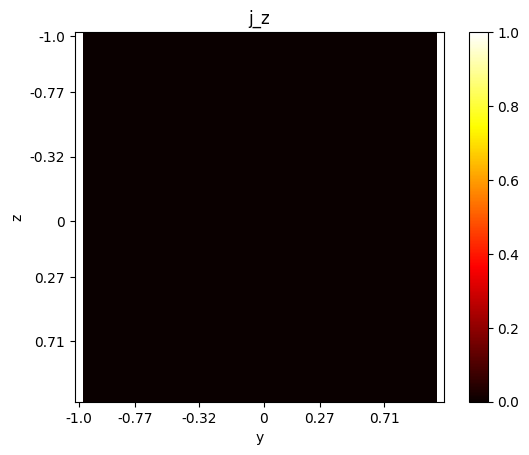

In [5]:
part_phi_z = gradF_data['timeseries'][
    :,
    :,
    :,
    gradF_data['labels'].index('dfdz'),
]
plot_heatmap(
    np.all(
        part_phi_z == 0,
        axis=0,
        ),
    title='part_phi_z',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )

j_z = fld_data['timeseries'][
    :,
    :,
    :,
    fld_data['labels'].index('jz'),
]
plot_heatmap(
    np.all(
        j_z == 0,
        axis=0,
        ),
    title='j_z',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )

### Calculate Sigma

c:\Users\hydro\anaconda3\envs\potential_probe\Lib\site-packages\ppvm_py\sigma_and_b_estimation.py:125: RuntimeWarning: invalid value encountered in divide
  sigma_est = np.divide(


mean(mean(sigma_est_ts)) = -0.999876509101196
mean(3 * std(sigma_est_ts)) = 0.26158065296789546
median(median(sigma_est_ts)) = -1.000011581939212


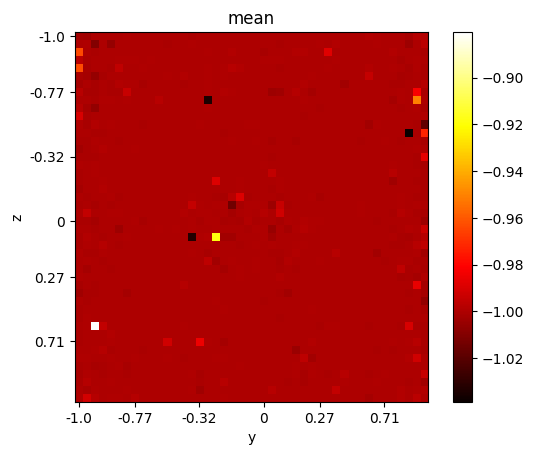

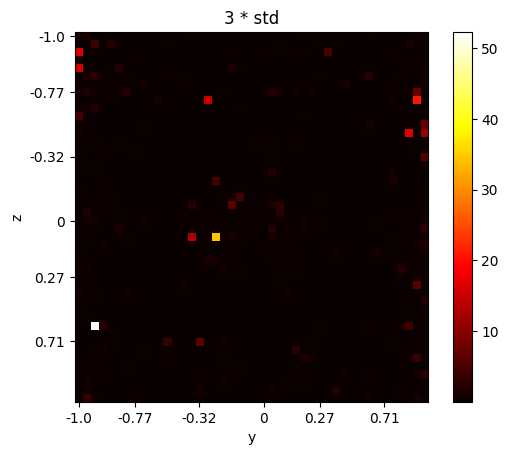

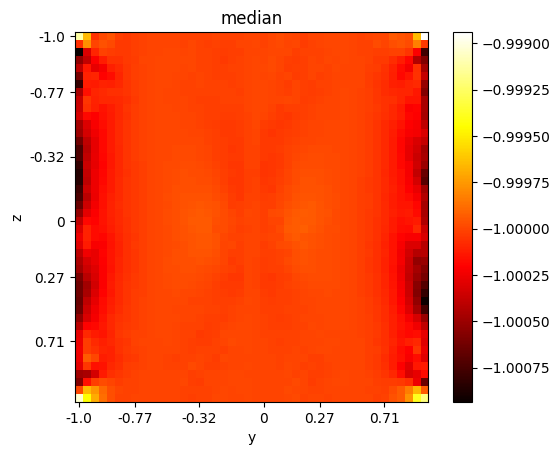

In [6]:
sigma_est_ts = calc_conductivity_with_z(
        partial_phi_data=gradF_data,
        partial_phi_label='dfdz',
        current_data=fld_data,
        current_label='jz',
        )
sigma_est_ts = sigma_est_ts[:, :, 1:-1]  # Exclude boundaries with 0 entries.

mean = np.mean(
        sigma_est_ts,
        axis=0,
        )
std = np.std(
        sigma_est_ts,
        axis=0,
        )
median = np.median(
        sigma_est_ts,
        axis=0,
        )

print(f"mean(mean(sigma_est_ts)) = {np.mean(mean)}")
print(f"mean(3 * std(sigma_est_ts)) = {np.mean(3 * std)}")
print(f"median(median(sigma_est_ts)) = {np.median(median)}")

plot_heatmap(
    mean,
    title='mean',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )
plot_heatmap(
    3*std,
    title='3 * std',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )
plot_heatmap(
    median,
    title='median',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )

## Ohm's Law in x-coord

### Find 0 Entries

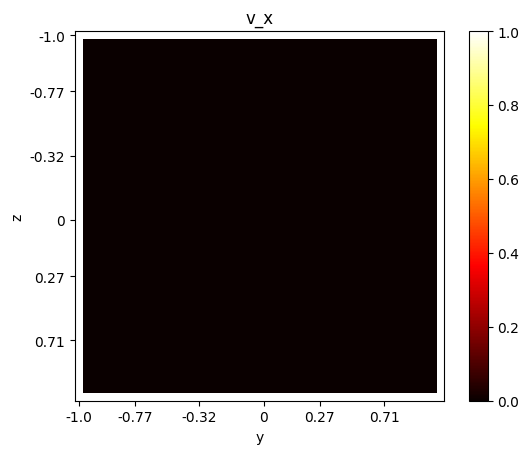

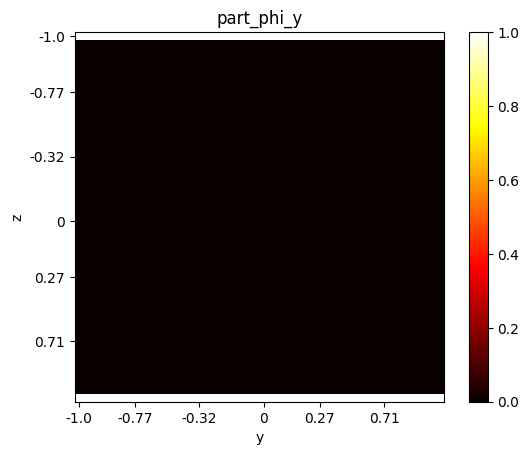

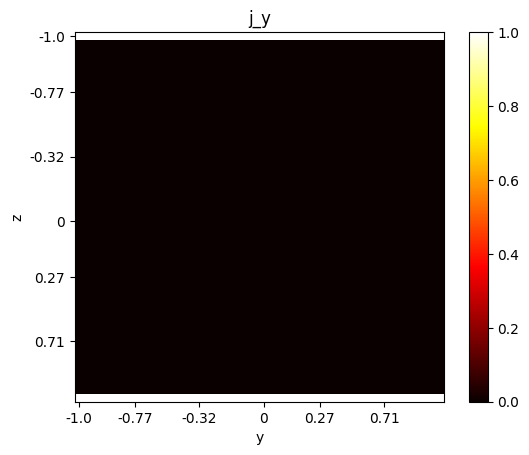

In [7]:
# v_x
v_x = fld_data['timeseries'][
    :,
    :,
    :,
    fld_data['labels'].index('vx'),
    ]
plot_heatmap(
    np.all(
        v_x == 0,
        axis=0,
        ),
    title='v_x',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )
v_x = v_x[:, 1:-1, 1:-1]


# part_phi_y
part_phi_y = gradF_data['timeseries'][
    :,
    :,
    :,
    gradF_data['labels'].index('dfdy'),
    ]
plot_heatmap(
    np.all(
        part_phi_y == 0,
        axis=0,
        ),
    title='part_phi_y',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )
part_phi_y = part_phi_y[:, 1:-1, 1:-1]


# j_y
j_y = fld_data['timeseries'][
    :,
    :,
    :,
    fld_data['labels'].index('jy'),
    ]
plot_heatmap(
    np.all(
        j_y == 0,
        axis=0,
        ),
    title='j_y',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )
j_y = j_y[:, 1:-1, 1:-1]

### Estimate $B_z$

In [8]:
B_z_est = np.divide(
    part_phi_y - j_y / sigma,
    v_x,
)

##### Mean

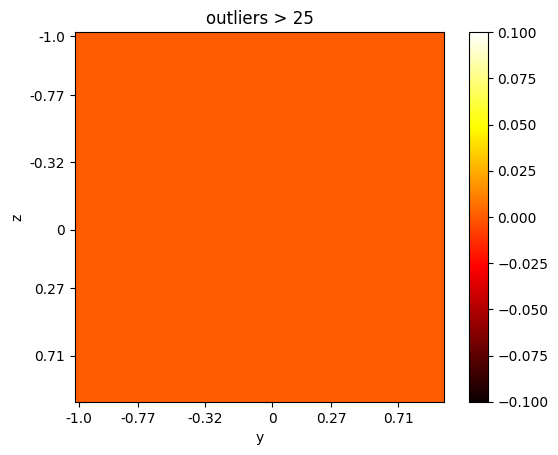

mean(mean(B_z_est) | mean(B_z_est) < 25) = -0.9989831842485413


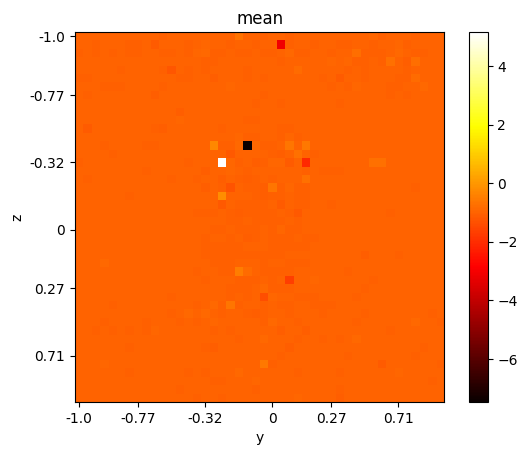

In [9]:
mean = np.mean(
    B_z_est,
    axis=0,
)

plot_heatmap(
    mean > 25,
    title='outliers > 25',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
)
print(f"mean(mean(B_z_est) | mean(B_z_est) < 25) = {np.mean(mean[mean < 25])}")


# Adjust outlier for better plot.
mean_wo_outlier = mean.copy()
mean_wo_outlier[mean_wo_outlier > 25] = np.median(mean_wo_outlier)

plot_heatmap(
    mean_wo_outlier,
    title='mean',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
)

##### 3-Std-Dev

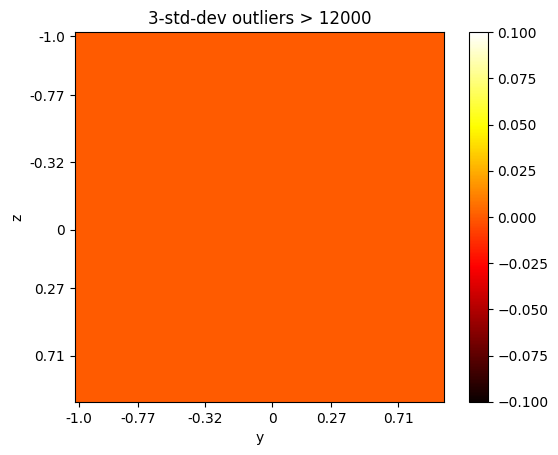

mean(3 * std(B_z_est) | 3 * std(B_z_est) < 12000) = 8.83425411570525


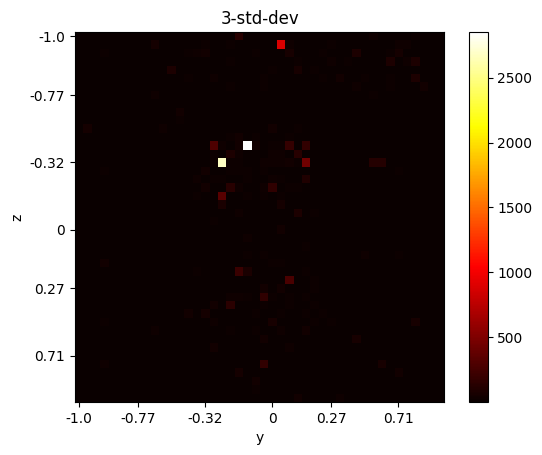

In [10]:
std = np.std(
    B_z_est,
    axis=0,
)
std_3 = 3 * std

plot_heatmap(
    std_3 > 12000,
    title='3-std-dev outliers > 12000',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
)
print(f"mean(3 * std(B_z_est) | 3 * std(B_z_est) < 12000) = {np.mean(std_3[std_3 < 12000])}")

# Adjust outlier for better plot.
std_3_wo_outlier = std_3.copy()
std_3_wo_outlier[std_3_wo_outlier > 12000] = np.median(std_3_wo_outlier)

plot_heatmap(
    std_3_wo_outlier,
    title='3-std-dev',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
)

##### Median

median(median(B_z_est)) = -0.9998351316034124


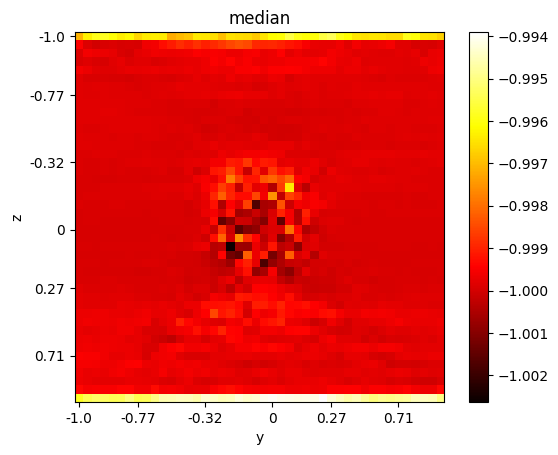

In [11]:
median = np.median(
    B_z_est,
    axis=0,
)

print(f"median(median(B_z_est)) = {np.median(median)}")
plot_heatmap(
    median,
    title='median',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
)

### Calculate Sigma

$\sigma = \frac{j_y}{\frac{\partial{\phi}}{\partial{y}} - v_x * B_z}$

##### Epsilon on 0 Divisors

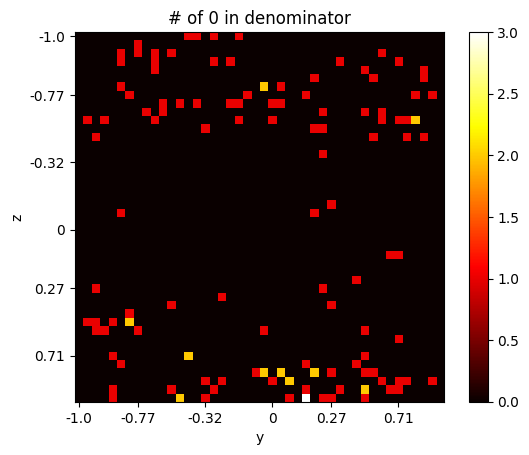

In [12]:
divisor = part_phi_y - v_x * B_z
# plot_heatmap(
#     np.any(
#         divisor == 0,
#         axis=0,
#         ),
#     title='divisor',
#     x_label='y',
#     y_label='z',
#     index_to_space_dict=fld_data['index_to_coord_map'],
#     round_decimals=2,
#     max_ticks=7,
#     )
plot_heatmap(
    np.sum(divisor == 0, axis=0),
    title='# of 0 in denominator',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
)
epsilon = 10e-100
divisor_plus_eps = divisor.copy()
divisor_plus_eps[divisor == 0] += epsilon

##### Main

mean(mean(sigma_est_ts)) = -0.9974566927550229
mean(3 * std(sigma_est_ts)) = 64.2028177428026
median(median(sigma_est_ts)) = -0.9970601036401818


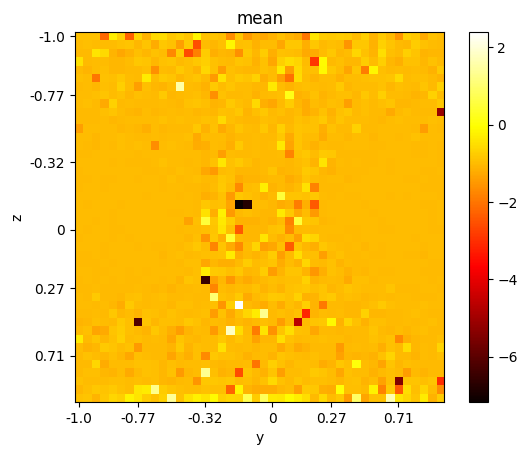

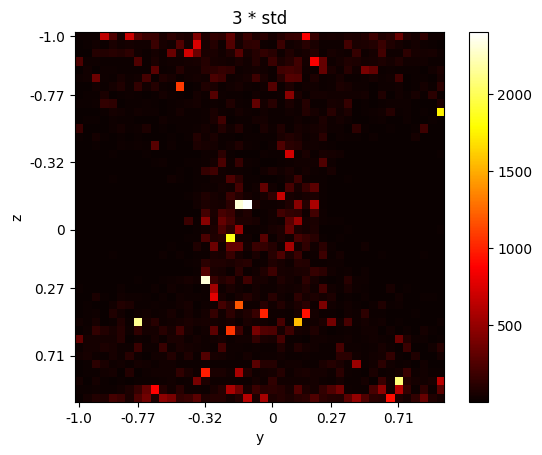

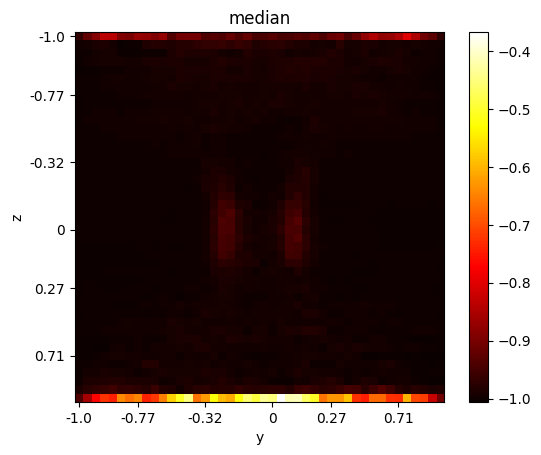

In [13]:
sigma_est_ts = np.divide(
    j_y,
    divisor_plus_eps,
)

mean = np.mean(
        sigma_est_ts,
        axis=0,
        where=(divisor != 0),
        )
std = np.std(
        sigma_est_ts,
        axis=0,
        where=(divisor != 0),
        )
std3 = 3 * std
median = np.median(
        sigma_est_ts,
        axis=0,
        )

mean_mean = np.mean(
    mean,
    )
mean_std3 = np.mean(
    std3,
    )
median_median = np.median(
    median,
    )

# # Exclude 0 entries
# mean_mean = np.mean(
#     mean[np.all(
#         divisor != 0,
#         axis=0,
#         )],
#     )
# mean_std3 = np.mean(
#     std3[np.all(
#         divisor != 0,
#         axis=0,
#         )],
#     )
# median_median = np.median(
#     median[np.all(
#         divisor != 0,
#         axis=0,
#         )],
#     )

print(f"mean(mean(sigma_est_ts)) = {mean_mean}")
print(f"mean(3 * std(sigma_est_ts)) = {mean_std3}")
print(f"median(median(sigma_est_ts)) = {median_median}")

plot_heatmap(
    mean,
    title='mean',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )
plot_heatmap(
    std3,
    title='3 * std',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )
plot_heatmap(
    median,
    title='median',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )

### Why no uniform $\sigma$?

Rationale: Look at the following $\min{j_y}$:

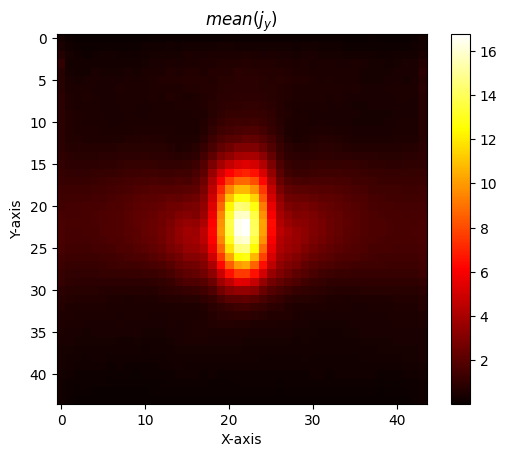

In [14]:
plot_heatmap(
    np.mean(np.abs(j_y), axis=0),
    title="$mean(j_y)$",
)

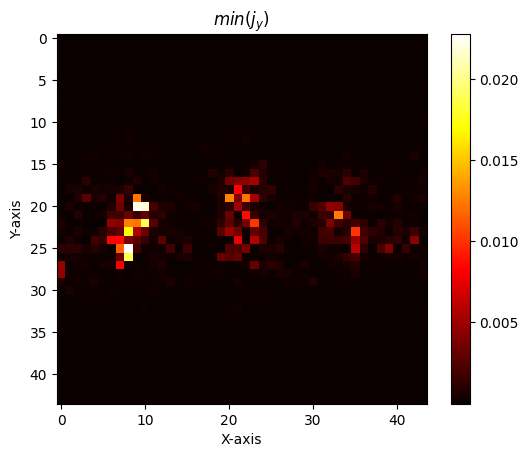

In [15]:
plot_heatmap(
    np.min(np.abs(j_y), axis=0),
    title="$min(j_y)$",
)

Sigma is expected to be $-1$, therefore, denominator and numerator should be more or less equal in abs terms. But for really small values, which we see we have, numerical problems are expected, and they do not fit. Particularly, we have some 0 within them as we have seen before. In the top and bottom region we have especially small values, so there, the sigma estimates are particularly off.